# 1.3 Gaussian city

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a city

In [1]:
config = {
    "city_width":21, # km
    "n_cores":1, # km
    "density_sigma":6, # Gaussian sigma
}

from city_simulator import City

city = City(config)
city.name

'Verona'

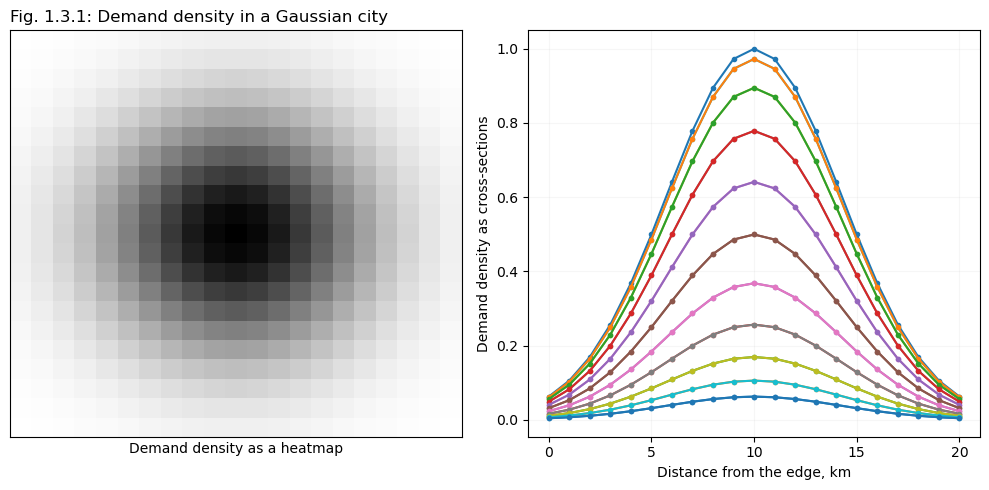

In [6]:
# Population density

# Visualize the city
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(city.grid.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.xticks([], [])
plt.yticks([], [])
plt.title("Fig. 1.3.1: Demand density in a Gaussian city", loc='left')

plt.subplot(122);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.grid, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.tight_layout()
plt.savefig("../figures/01simple_03city_01population.svg", dpi=300)

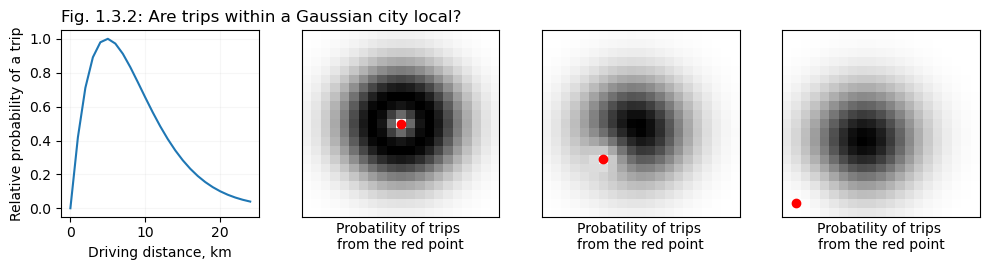

In [8]:
# Spatial mobility curve

n_grid = city.grid_size
density = city.grid

def trip_probability(distance):
    y = distance*np.exp(-(distance**1.2)/8) / 2.11
    return y

x = np.arange(0, 25)
curve = trip_probability(x)

def generate_local_map(i0, j0):
    local_trips = np.zeros(shape=(n_grid, n_grid))
    for i in range(n_grid):
        for j in range(n_grid):
            distance = np.sqrt((i-i0)**2 + (j-j0)**2)*config["grid_step"]        
            local_trips[i, j] = trip_probability(distance)
    local_trips *= density
    local_trips /= local_trips.flatten().max()
    return local_trips

# Figure
plt.figure(figsize=(10, 2.8))
plt.subplot(141)
plt.plot(x, curve)
plt.grid(alpha=0.1)
plt.xlabel('Driving distance, km')
plt.ylabel('Relative probability of a trip')
plt.title("Fig. 1.3.2: Are trips within a Gaussian city local?", loc='left');

plt.subplot(142)
plt.imshow(generate_local_map(10, 10).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(10+0.5, 10+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(143)
plt.imshow(generate_local_map(6, 6).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(6+0.5, 6+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(144)
plt.imshow(generate_local_map(1, 1).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(1+0.5, 1+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.savefig("../figures/01simple_03city_02mobility.svg", dpi=300)

# Fast city simulation

Initializing...
Generated Gaussian demand map (sigma=1.50 km)
Initialization complete (0.01s)
Starting simulation for 100 steps (Stats from step 5)...
Simulation complete (3.30s)
Statistics collected over 95 ticks.
Generating plots...


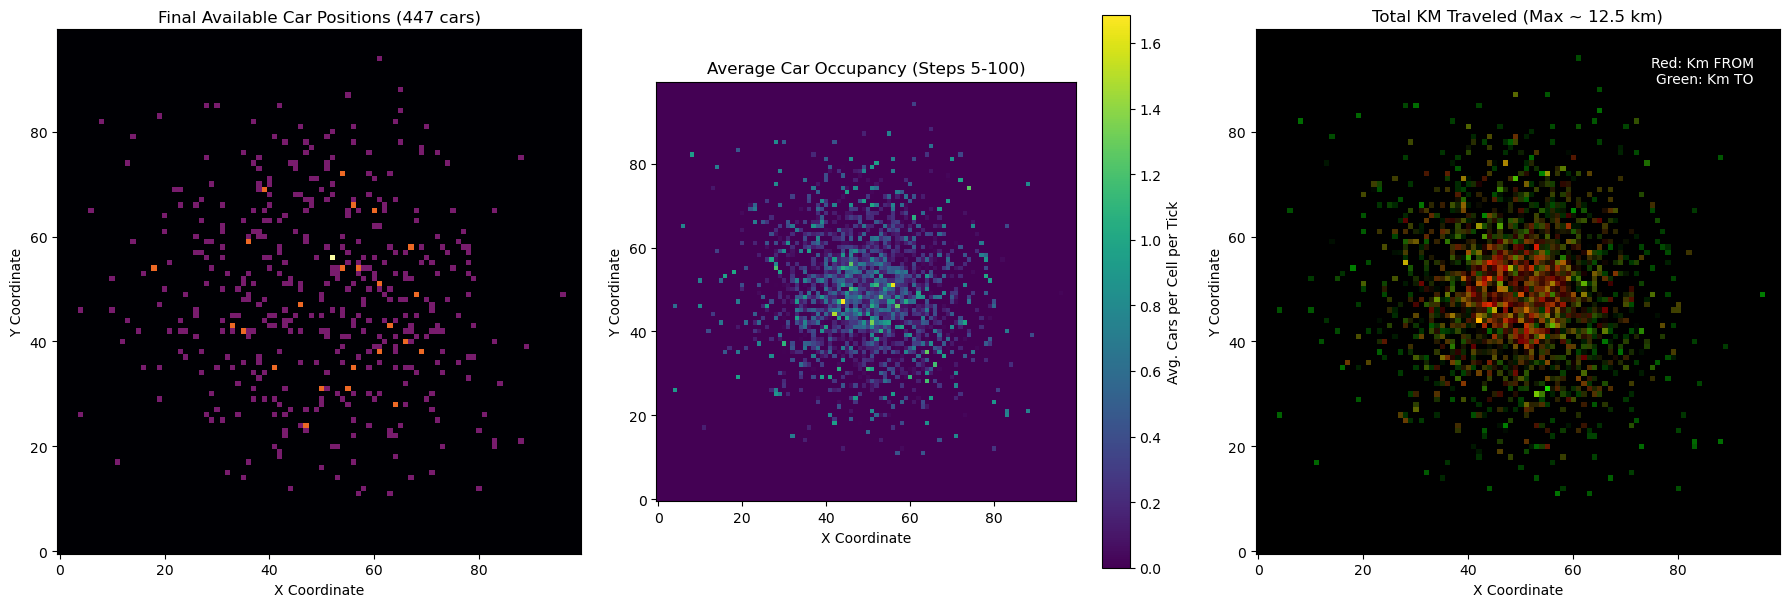

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image # For image demand loading

# --- Parameters ---
# Simulation Control
N_STEPS = 100           # Total simulation steps
STATS_START_STEP = 5   # Step to start collecting statistics (burn-in)
DEMAND_MODE = 'gaussian'  # 'gaussian' or 'image'

# City & Grid
GRID_SIZE = 100           # Lower grid size for reasonable performance with stats/transit
CITY_WIDTH_KM = 10.0      # Physical width of the city

# Demand Generation ('gaussian' mode)
DEMAND_SIGMA_KM = 1.5     # Gaussian spread in km

# Demand Generation ('image' mode)
DEMAND_IMAGE_PATH = 'demand_map.jpg' # Replace with your image file path
# Note: Image will be resized to GRID_SIZE x GRID_SIZE.
# Image interpretation: White pixels = 0 demand, Black pixels = 1 demand.

# Cars & Movement
N_CARS = 500
INITIAL_RADIUS_KM = 1.0   # Initial placement radius in km
AVG_SPEED_KMH = 30.0
TICK_DURATION_MINUTES = 1 # Duration of one simulation tick in minutes
RENTAL_PROB_FACTOR = 0.08 # Scaled based on tick duration (tune this)
DISTANCE_PENALTY_FACTOR = 0.5 # Higher = shorter trips more preferred (tune this)

# Internal Constants & Derived Parameters
EPSILON = 1e-9
KM_PER_PIXEL = CITY_WIDTH_KM / GRID_SIZE
INITIAL_RADIUS_PIXELS = INITIAL_RADIUS_KM / KM_PER_PIXEL
DEMAND_SIGMA_PIXELS = DEMAND_SIGMA_KM / KM_PER_PIXEL
TICK_DURATION_HOURS = TICK_DURATION_MINUTES / 60.0
AVG_SPEED_PIXELS_PER_HOUR = AVG_SPEED_KMH / KM_PER_PIXEL
AVG_SPEED_PIXELS_PER_TICK = AVG_SPEED_PIXELS_PER_HOUR * TICK_DURATION_HOURS

# Car States
ST_AVAILABLE = 0
ST_IN_TRANSIT = 1

# --- Initialization ---
print("Initializing...")
start_time_init = time.time()

# 1. Generate Demand Map
if DEMAND_MODE == 'gaussian':
    center = (GRID_SIZE - 1) / 2
    y_coords, x_coords = np.ogrid[:GRID_SIZE, :GRID_SIZE]
    dist_sq_from_center = (x_coords - center)**2 + (y_coords - center)**2
    sigma_sq = max(DEMAND_SIGMA_PIXELS**2, EPSILON)
    demand_map = np.exp(-dist_sq_from_center / (2 * sigma_sq))
    demand_map /= np.max(demand_map) # Normalize
    print(f"Generated Gaussian demand map (sigma={DEMAND_SIGMA_KM:.2f} km)")
elif DEMAND_MODE == 'image':
    try:
        img = Image.open(DEMAND_IMAGE_PATH).convert('L') # Open and convert to grayscale
        img_resized = img.resize((GRID_SIZE, GRID_SIZE), Image.Resampling.LANCZOS)
        img_array = np.array(img_resized, dtype=np.float32)
        # Invert (assuming 0=black, 255=white -> we want black=1, white=0)
        demand_map = 1.0 - (img_array / 255.0)
        demand_map = np.clip(demand_map, 0, 1) # Ensure values are in [0, 1]
        print(f"Loaded demand map from '{DEMAND_IMAGE_PATH}' and resized to {GRID_SIZE}x{GRID_SIZE}")
    except FileNotFoundError:
        print(f"Error: Demand image '{DEMAND_IMAGE_PATH}' not found. Exiting.")
        exit()
    except Exception as e:
        print(f"Error loading demand image: {e}. Exiting.")
        exit()
else:
    print(f"Error: Unknown DEMAND_MODE '{DEMAND_MODE}'. Exiting.")
    exit()

flat_demand = demand_map.flatten()

# 2. Precompute Grid Data
all_coords_flat_idx = np.arange(GRID_SIZE * GRID_SIZE)
flat_y, flat_x = np.unravel_index(all_coords_flat_idx, (GRID_SIZE, GRID_SIZE))
flat_grid_coords = np.stack((flat_x, flat_y), axis=1) # Shape: (N_cells, 2)

# 3. Initialize Cars
center_pixels = (GRID_SIZE - 1) / 2
angles = 2 * np.pi * np.random.rand(N_CARS)
radii = np.sqrt(np.random.rand(N_CARS)) * INITIAL_RADIUS_PIXELS
car_x = np.clip(np.round(center_pixels + radii * np.cos(angles)), 0, GRID_SIZE - 1).astype(int)
car_y = np.clip(np.round(center_pixels + radii * np.sin(angles)), 0, GRID_SIZE - 1).astype(int)
car_positions = np.stack((car_x, car_y), axis=1) # Current location IF available
car_destinations = np.zeros_like(car_positions)  # Where the car is going
car_states = np.full(N_CARS, ST_AVAILABLE, dtype=np.int8)
car_transit_timers = np.zeros(N_CARS, dtype=np.int32) # Remaining ticks in transit
car_current_trip_distance_km = np.zeros(N_CARS, dtype=np.float32) # Store distance for stats

# 4. Initialize Statistics Arrays
occupancy_ticks_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
km_traveled_from_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
km_traveled_to_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)

print(f"Initialization complete ({time.time() - start_time_init:.2f}s)")

# --- Simulation Loop ---
print(f"Starting simulation for {N_STEPS} steps (Stats from step {STATS_START_STEP})...")
start_time_sim = time.time()

for step in range(N_STEPS):
    collect_stats = step >= STATS_START_STEP

    # --- 1. Handle Arrivals & Update State ---
    in_transit_mask = car_states == ST_IN_TRANSIT
    arriving_mask = np.zeros(N_CARS, dtype=bool) # Track arrivals this step for stats

    if np.any(in_transit_mask):
        # Decrement timers for cars in transit
        car_transit_timers[in_transit_mask] -= 1

        # Identify cars arriving *this* tick
        arriving_mask = in_transit_mask & (car_transit_timers <= 0)
        arriving_indices = np.where(arriving_mask)[0]

        if len(arriving_indices) > 0:
            # Update state and position for arriving cars
            car_states[arriving_mask] = ST_AVAILABLE
            car_positions[arriving_mask] = car_destinations[arriving_mask]

            # Accumulate "traveled to" stats (if collecting)
            if collect_stats:
                dest_y = car_positions[arriving_mask, 1]
                dest_x = car_positions[arriving_mask, 0]
                distances_arrived = car_current_trip_distance_km[arriving_mask]
                np.add.at(km_traveled_to_map, (dest_y, dest_x), distances_arrived)

            # Reset trip distance for arrived cars
            car_current_trip_distance_km[arriving_mask] = 0.0

    # --- 2. Accumulate Occupancy Stats ---
    available_mask = car_states == ST_AVAILABLE
    if collect_stats and np.any(available_mask):
        current_pos_available = car_positions[available_mask]
        # Use add.at to increment counts at the locations of available cars
        np.add.at(occupancy_ticks_map, (current_pos_available[:, 1], current_pos_available[:, 0]), 1.0)

    # --- 3. Identify Potential Rentals (from Available Cars) ---
    available_indices = np.where(available_mask)[0]
    if len(available_indices) == 0:
        continue # Skip if no cars are available to rent

    start_pos_available = car_positions[available_mask]
    start_demands_available = demand_map[start_pos_available[:, 1], start_pos_available[:, 0]]

    # Probability depends on start demand and base factor
    consider_move_prob = start_demands_available * RENTAL_PROB_FACTOR
    # Decide which available cars *consider* moving
    roll_the_dice = np.random.rand(len(available_indices))
    potential_trip_mask_rel = roll_the_dice < consider_move_prob # Mask relative to available cars
    potential_trip_indices_abs = available_indices[potential_trip_mask_rel] # Absolute indices in N_CARS

    if len(potential_trip_indices_abs) == 0:
        continue # Skip if no one is starting a trip

    # --- 4. Select Destinations for Potential Trips ---
    start_pos_potential = car_positions[potential_trip_indices_abs] # (N_potential, 2)
    n_potential = len(potential_trip_indices_abs)

    # Calculate log-scores for all destinations for these potential movers
    dx = start_pos_potential[:, 0, np.newaxis] - flat_grid_coords[np.newaxis, :, 0]
    dy = start_pos_potential[:, 1, np.newaxis] - flat_grid_coords[np.newaxis, :, 1]
    distances_pixels = np.hypot(dx, dy) # Shape: (N_potential, N_cells)

    log_scores = (np.log(flat_demand[np.newaxis, :] + EPSILON)
                  - np.log(1.0 + distances_pixels * DISTANCE_PENALTY_FACTOR))

    # Mask out the starting location itself
    start_flat_indices = np.ravel_multi_index((start_pos_potential[:, 1], start_pos_potential[:, 0]), (GRID_SIZE, GRID_SIZE))
    log_scores[np.arange(n_potential), start_flat_indices] = -np.inf

    # Use Gumbel-Max trick to sample destinations
    gumbel_noise = -np.log(-np.log(np.random.rand(n_potential, GRID_SIZE * GRID_SIZE) + EPSILON) + EPSILON)
    chosen_flat_indices = np.argmax(log_scores + gumbel_noise, axis=1) # (N_potential,)

    # --- 5. Initiate Trips ---
    new_y, new_x = np.unravel_index(chosen_flat_indices, (GRID_SIZE, GRID_SIZE))
    chosen_destinations = np.stack((new_x, new_y), axis=1) # (N_potential, 2)

    # Get distances corresponding to the chosen destinations
    chosen_distances_pixels = distances_pixels[np.arange(n_potential), chosen_flat_indices]
    chosen_distances_km = chosen_distances_pixels * KM_PER_PIXEL

    # Calculate transit time in ticks (at least 1 tick)
    transit_time_ticks = np.maximum(1, np.round(chosen_distances_pixels / max(AVG_SPEED_PIXELS_PER_TICK, EPSILON))).astype(np.int32)

    # Update state for cars starting the trip
    car_states[potential_trip_indices_abs] = ST_IN_TRANSIT
    car_transit_timers[potential_trip_indices_abs] = transit_time_ticks
    car_destinations[potential_trip_indices_abs] = chosen_destinations
    car_current_trip_distance_km[potential_trip_indices_abs] = chosen_distances_km
    # Note: car_positions is NOT updated here; the car is now "off map"

    # Accumulate "traveled from" stats (if collecting)
    if collect_stats:
        start_y = start_pos_potential[:, 1]
        start_x = start_pos_potential[:, 0]
        np.add.at(km_traveled_from_map, (start_y, start_x), chosen_distances_km)


# --- Simulation End ---
sim_duration = time.time() - start_time_sim
print(f"Simulation complete ({sim_duration:.2f}s)")
actual_stat_ticks = max(0, N_STEPS - STATS_START_STEP)
print(f"Statistics collected over {actual_stat_ticks} ticks.")

# --- Plotting Results ---
print("Generating plots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size

# Plot 1: Final Available Car Positions (Snapshot)
ax = axes[0]
final_available_mask = car_states == ST_AVAILABLE
if np.any(final_available_mask):
    final_positions = car_positions[final_available_mask]
    ax.hist2d(
        final_positions[:, 0], final_positions[:, 1],
        bins=GRID_SIZE, range=[[-0.5, GRID_SIZE - 0.5], [-0.5, GRID_SIZE - 0.5]],
        cmap='inferno'
    )
    ax.set_title(f'Final Available Car Positions ({np.sum(final_available_mask)} cars)')
else:
    ax.set_title('No Cars Available at End')
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_aspect('equal', adjustable='box')

# Plot 2: Average Occupancy (normalized by collection time)
ax = axes[1]
if actual_stat_ticks > 0:
    avg_occupancy_map = occupancy_ticks_map / actual_stat_ticks
    im = ax.imshow(avg_occupancy_map, cmap='viridis', origin='lower', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg. Cars per Cell per Tick')
    ax.set_title(f'Average Car Occupancy (Steps {STATS_START_STEP}-{N_STEPS})')
else:
    ax.set_title('No Statistics Collected')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_aspect('equal', adjustable='box')

# Plot 3: Total KM Traveled FROM / TO (Using color channels)
# We can visualize From (Red) and To (Green) in one plot. Blue can be average? Or just two plots.
# Let's do two separate plots for clarity or combine into RGB. Let's try RGB.
ax = axes[2]
if actual_stat_ticks > 0:
    # Normalize KM maps for visualization (e.g., relative to max km)
    max_km_from = np.max(km_traveled_from_map)
    max_km_to = np.max(km_traveled_to_map)
    max_km = max(max_km_from, max_km_to, EPSILON) # Use a common scale

    norm_km_from = km_traveled_from_map / max_km
    norm_km_to = km_traveled_to_map / max_km
    # Create an RGB image: R=From, G=To, B=0
    # Clamp values just in case, though normalization should handle it
    rgb_image = np.stack([
        np.clip(norm_km_from, 0, 1),
        np.clip(norm_km_to, 0, 1),
        np.zeros_like(norm_km_from) # Blue channel
    ], axis=-1)

    im = ax.imshow(rgb_image, origin='lower', interpolation='nearest')
    # Custom legend substitute for RGB plot
    ax.text(0.95, 0.95, 'Red: Km FROM\nGreen: Km TO', transform=ax.transAxes,
            ha='right', va='top', color='white', bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))
    ax.set_title(f'Total KM Traveled (Max ~ {max_km:.1f} km)')

else:
     ax.set_title('No Statistics Collected')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()